# Free-vocabulary logic labels and metric test: solver consensus vs an LLM judge

**Artifact:** `art_5KczEbsFPx25` (iteration 5, `gen_art_experiment_13`). It is part of a study of **gold-free metrics for
natural-language → first-order-logic (NL→FOL) translations**.

**The question.** Several LLM systems each translate the same sentence into FOL. The candidate metric,
**cross-family solver consensus `c_score_align`**, is the share of *other model families'* translations that a solver finds
**not** logically equivalent to this one, after predicate alignment. Higher means the translation is more likely an ERROR.
The test asks whether this metric predicts faithfulness better than a cheap LLM-as-judge baseline (the flash-lite
rubric-A judge). The judge scores each translation in two views: a *disguised* view (renamed entities, so the judge cannot
recall the public gold annotation) and the *original* view.

**What the full run found:**
* The confirmatory test is **NOT_TESTABLE**. Correct labels needed a two-checker "gloss gate", and that gate failed twice,
  so under the pre-registered fallback B no row can be labelled CORRECT.
* The **provisional, non-confirmatory** comparison, ERROR_CERT (y=1) vs MAPPED (y=0) on untouched rows, still gives:
  * disguised view: within-template AUROC c_align 0.801 vs judge 0.584, **Δ = +0.217 [0.175, 0.260]**;
  * original view: **Δ = +0.171 [0.135, 0.206]**.
* A blind audit, a frontier judge and placebo checks back this up. See the artifact summary.

**What this notebook does.** `method.py` is the artifact's entry point, and it only *orchestrates* ~15 step scripts. Many
of those steps call paid LLM APIs and read multi-GB intermediate files. The notebook works as follows:
1. It keeps the original `method.py` orchestrator code verbatim, run in dry-run mode so it prints the pre-registered step
   plan.
2. It inlines the original **$0 analysis core** that the `analysis` step runs. That core is the stratified-AUROC and
   bootstrap machinery (`confirm/auc_tools.py`), the paired-delta and nesting statistics (`confirm/analysis_lib.py`), and
   the headline, complexity and placebo analyses (`confirm/join_and_test.py`). The notebook also includes the independent
   brute-force re-derivation (`tests/rederive_raw.py`).
3. It runs all of this on a curated, **stratified 100-row subset** of the sealed per-item table (`mini_demo_data.json`):
   9 templates × {ERROR_CERT, MAPPED}, one row per sentence. The subset has 100 rows where the full run had ~1,700, so
   its numbers are noisier. The full-run reference values are printed next to them.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (method.py logs with it)
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# --- original method.py imports ---
import argparse
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- imports of the analysis modules inlined below (confirm/auc_tools.py, confirm/analysis_lib.py,
#     confirm/join_and_test.py, confirm/cc.py, tests/rederive_raw.py) ---
import hashlib
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# --- notebook-only: visualization ---
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{data['n_examples']} demo rows (drawn from a pool of {data['n_pool']} eligible untouched rows)")
print("full-run verdict:", data["full_run_reference"]["verdict"])
ex = data["examples"][0]
print("\nexample text :", ex["text"])
print("candidate FOL:", ex["candidate_fol"])
print("label        :", ex["label"], "| c_score_align =", ex["c_score_align"], "| judge_cheap_disg =", ex["judge_cheap_disg"])

Curated 100-row subset of R_COMP FREE (untouched, ERROR_CERT=y1 vs MAPPED/UNRESOLVED_GLOSS_GATE_FAILED=y0), stratified by template x label. Scores: higher = more likely ERROR.
100 demo rows (drawn from a pool of 1618 eligible untouched rows)
full-run verdict: NOT_TESTABLE

example text : Every photographer who commits a crime, who lives in a large city, and who has a talent of cooking is born in New York City, unless the photographer takes more than normal financial risks.
candidate FOL: ∀x ((Photographer(x) ∧ Commits(x, crime) ∧ LivesIn(x, y) ∧ LargeCity(y) ∧ HasTalent(x, cooking) ∧ ¬TakesMoreThanNormalFinancialRisks(x)) → BornIn(x, newYorkCity))
label        : ERROR_CERT | c_score_align = 1.0 | judge_cheap_disg = 0.9


## Configuration

All tunable parameters live in this cell. The values are small enough for the notebook to finish quickly. The original
values used by the full run are in the comments.

In [5]:
B = 2000                 # bootstrap replicates (template-stratified sentence bootstrap)   — original: 2000 (confirm/cc.py)
SEED = 20260924          # bootstrap / permutation seed                                    — original: 20260924
N_PERM = 50              # label permutations per nesting null (with refits)               — original: 50
N_SHUFFLE = 20           # within-template label-shuffle placebos (+100 supplement if >=20) — original: 20
REDERIVE_B = 1000        # bootstrap replicates of the independent re-derivation            — original: 1000 (tests/rederive_raw.py)
REDERIVE_PERM_B = 500    # bootstrap replicates of the permuted-label re-derivation         — original: 500
RUN_STEPS = "analysis,report,checks"   # method.py --steps (default: the $0 tail)
DRY_RUN = True           # the step scripts are not bundled with the demo, so method.py only prints its plan

## 1. The entry point: `method.py` (orchestrator)

This is the original `method.py`. Its docstring gives the **pre-registered order of steps**. Each step is its own
script, and the paid steps (judge, gloss gate, audit, frontier) are cached and ledgered. Order matters here:
* scores were **sealed** (hashed) *before* any label-producing gloss call;
* the prereg was git-committed before the gate ran.

Notebook changes, kept to the minimum:
* `WS` is the current directory, because `__file__` does not exist in a notebook.
* `argparse` reads `RUN_STEPS` from the config instead of the CLI.
* With `DRY_RUN = True` the notebook logs each command instead of launching the step scripts, which are not bundled here.
  The `analysis` step's $0 core is reproduced in the cells that follow.

In [6]:
"""R_COMP FREE confirmation of criterion (c): the metric (cross-family solver consensus c_score_align) vs the baseline
(the flash-lite rubric-A LLM judge, disguised and original views; plus local Qwen3-8B, frontier gemini-3.1-pro, c_exact
and the V1-V5 consensus variants), on free-vocabulary templated long sentences.

This is the entry point. It runs every step in the pre-registered order; each step is its own script. Paid steps are
cached and ledgered, so re-running them never re-bills. Steps:
  g0         $0  reproduce exp-7 SIG AUROCs (0.954 / 0.587)                         confirm/g0_repro.py
  judge_orig paid label-blind completion of the original-view judge (D16)          confirm/judge_orig_complete.py
  scores     $0  sealed score table + score seal (BEFORE any gloss call)            confirm/scores.py
  prereg     $0  prereg_rcomp_confirm.json (+ git commit, done once)                confirm/prereg.py
  pilot      paid gloss cost pilot + projection                                     confirm/gloss_pilot.py
  gate       paid gloss gate half A (gloss_v1); then half B (gloss_v2)             labeller/src/resume_gloss.py gate, gate.py
  gate_diag  $0  failure diagnostics (FALLBACK B)                                   confirm/gate_diagnostics.py
  finalize   $0  final labels + seal + post-seal join                               labeller/src/resume_gloss.py finalize
  audit      paid blind two-family audit (Sonnet-5 + GLM-4.6)                       confirm/audit_blind.py
  frontier   paid STEP F frontier judge (150 rows)                                  confirm/frontier_judge.py
  analysis   $0  verify seals, join ONCE, all analyses                              confirm/join_and_test.py
  report     $0  verdict, tables.md, method_out.json                                confirm/report.py
  checks     $0  re-derivation, deviations, ledger, final checks                    tests/rederive_confirm.py, confirm/final_checks.py
usage: uv run method.py [--steps analysis,report,checks]   (default: the $0 tail: analysis,report,checks)
"""
WS = Path.cwd()  # notebook: was Path(__file__).resolve().parent
PY = sys.executable
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs/method.log", rotation="30 MB", level="DEBUG")

STEPS = {
    "g0": [["confirm/g0_repro.py"]],
    "judge_orig": [["confirm/judge_orig_complete.py"]],
    "scores": [["confirm/scores.py"]],
    "prereg": [["confirm/prereg.py"]],
    "pilot": [["confirm/gloss_pilot.py"]],
    "gate": [["labeller/src/resume_gloss.py", "gate"], ["labeller/src/gate.py", "run", "--half", "B", "--version", "gloss_v2"]],
    "gate_diag": [["confirm/gate_diagnostics.py"]],
    "finalize": [["labeller/src/resume_gloss.py", "finalize", "--version", "gloss_v2"]],
    "audit": [["confirm/audit_blind.py"]],
    "frontier": [["confirm/frontier_judge.py"]],
    "analysis": [["confirm/join_and_test.py"]],
    "report": [["confirm/report.py"]],
    "checks": [["tests/rederive_confirm.py"], ["confirm/write_deviations.py"], ["confirm/final_checks.py"]],
}


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--steps", default="analysis,report,checks")
    a = ap.parse_args(["--steps", RUN_STEPS])  # notebook: CLI args come from the config cell
    for st in a.steps.split(","):
        for cmd in STEPS[st]:
            script = WS / cmd[0]
            cwd = script.parent if cmd[0].startswith("confirm/") else (WS / "labeller" if cmd[0].startswith("labeller/") else WS)
            args = [PY, str(script)] + cmd[1:]
            if cmd[0].startswith("labeller/"):
                args = [PY, str(Path(cmd[0]).relative_to("labeller"))] + cmd[1:]
            logger.info(f"[{st}] $ {' '.join(args)}")
            if not DRY_RUN:  # notebook: step scripts are not bundled with the demo
                subprocess.run(args, check=True, cwd=cwd)
    logger.info("done")


main()

13:28:22|INFO   |[analysis] $ /tmp/aii_nb_test_envs/art_5KczEbsFPx25-5d4ceb7c5e8f/bin/python /ai-inventor/aii_data/runs/run_qck1d05BqxkX/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_5/art_5KczEbsFPx25/confirm/join_and_test.py


13:28:22|INFO   |[report] $ /tmp/aii_nb_test_envs/art_5KczEbsFPx25-5d4ceb7c5e8f/bin/python /ai-inventor/aii_data/runs/run_qck1d05BqxkX/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_5/art_5KczEbsFPx25/confirm/report.py


13:28:22|INFO   |[checks] $ /tmp/aii_nb_test_envs/art_5KczEbsFPx25-5d4ceb7c5e8f/bin/python /ai-inventor/aii_data/runs/run_qck1d05BqxkX/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_5/art_5KczEbsFPx25/tests/rederive_confirm.py


13:28:22|INFO   |[checks] $ /tmp/aii_nb_test_envs/art_5KczEbsFPx25-5d4ceb7c5e8f/bin/python /ai-inventor/aii_data/runs/run_qck1d05BqxkX/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_5/art_5KczEbsFPx25/confirm/write_deviations.py


13:28:22|INFO   |[checks] $ /tmp/aii_nb_test_envs/art_5KczEbsFPx25-5d4ceb7c5e8f/bin/python /ai-inventor/aii_data/runs/run_qck1d05BqxkX/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_5/art_5KczEbsFPx25/confirm/final_checks.py


13:28:22|INFO   |done


## 2. Stratified, cluster-weighted AUROC (`confirm/auc_tools.py`, verbatim)

The primary statistic is a **within-template AUROC**. R_COMP sentences come from 9 English templates, and a pooled AUROC
would partly reward a metric for simply telling templates apart. So ERROR × CORRECT pairs are counted only *inside*
each template, and then pooled: `sum_s U_s / sum_s P_s`.

Uncertainty comes from a **sentence (cluster) bootstrap**. Sentences are resampled with replacement *within their
template*, and every row inherits its sentence's multiplicity. `StratAUC` ranks the scores once, so each bootstrap
replicate is O(n).

In [7]:
"""Stratified, cluster-weighted AUROC machinery for S10 (pure numpy; no labels are read here).

auroc_within(stratum) = sum_s U_s / sum_s P_s where, inside stratum s, U_s counts ERROR x CORRECT pairs with the ERROR
row scored higher (ties 0.5) and P_s = n_err_s * n_cor_s. Stratum = one value for the pooled AUROC, template_id for the
primary statistic, sentence_id for the within-sentence robustness row.

Bootstrap weights: each replicate gives every sentence (cluster) an integer multiplicity k (sentences resampled with
replacement WITHIN each template). A row inherits the multiplicity of its sentence, so a pair (i, j) is weighted k_i*k_j
(identical to physically duplicating the rows). For the within-sentence stratum a duplicated sentence is a duplicated
stratum, so its pairs must count k (not k^2): rows then carry sqrt(k).
"""


class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}

## 3. Paired deltas and nesting (`confirm/analysis_lib.py`, verbatim excerpt)

* `Boot` draws **one** set of bootstrap weights over all sentences. Every metric, population and delta shares it, so a
  paired comparison (c_align − judge) uses exactly the same resamples for both sides.
* `paired_delta` gives AUROC(a) − AUROC(b) on the rows both metrics score, with a percentile CI and a two-sided
  bootstrap p-value.
* `nested_block` checks whether one signal **adds** information to another: `[base + add] − [base]`. It fits
  cross-fitted logistic models on 5 sentence folds, with features rank-normalised by the training fold's ECDF. The null
  comes from within-template label permutations, refitted each time.

The operating-point and Holm helpers are left out because this demo does not call them.

In [8]:
"""Statistics used by join_and_test.py: within-template AUROC with shared template-stratified sentence-bootstrap
weights, paired deltas, cross-fitted nesting, operating points and Holm. Orientation: higher score = more likely ERROR;
y = 1 means ERROR. Pure numpy / sklearn; no file I/O."""


class Boot:
    """One set of bootstrap weights over ALL sentences (clusters), resampled within template; shared by every metric,
    population and delta, so that paired comparisons use the SAME resamples."""

    def __init__(self, sentence_ids: list[str], sentence_template: dict, B: int, seed: int):
        self.sids = sorted(sentence_ids)
        self.ix = {s: i for i, s in enumerate(self.sids)}
        cs = np.array([sentence_template[s] for s in self.sids])
        self.W = boot_weights(cs, B, seed)
        self.B = B

    def cl(self, sids) -> np.ndarray:
        return np.array([self.ix[s] for s in sids], dtype=np.int64)


def _arr(df, col):
    return df[col].to_numpy(dtype=float)


def auc_block(df, score: str, boot: Boot, ycol: str = "y", stratum: str = "template_id", with_boot: bool = True) -> dict:
    d = df[df[score].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique()),
           "n_sent_err": int(d[y].sentence_id.nunique()), "n_sent_cor": int(d[~y].sentence_id.nunique())}
    if y.all() or (~y).all() or len(d) == 0:
        out.update(est=None, ci=[None, None], se=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    A = StratAUC(_arr(d, score), y, st, boot.cl(d.sentence_id))
    out["est"] = A.value()
    if with_boot:
        bs = np.array([A.value(boot.W[b]) for b in range(boot.B)])
        bs = bs[~np.isnan(bs)]
        out["ci"] = [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]
        out["se"] = float(np.std(bs, ddof=1))
    return out


def paired_delta(df, a: str, b: str, boot: Boot, ycol: str = "y", stratum: str = "template_id") -> dict:
    """AUROC_within(a) - AUROC_within(b) on rows where both are scored, same bootstrap weights."""
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    out = {"a": a, "b": b, "n": int(len(d)), "n_err": int(y.sum()), "n_cor": int((~y).sum()), "n_sent": int(d.sentence_id.nunique())}
    if len(d) == 0 or y.all() or (~y).all():
        out.update(delta=None, ci=[None, None], p_two_sided=None, auroc_a=None, auroc_b=None)
        return out
    st = d[stratum].to_numpy() if stratum != "pooled" else np.zeros(len(d))
    cl = boot.cl(d.sentence_id)
    A = StratAUC(_arr(d, a), y, st, cl)
    Bm = StratAUC(_arr(d, b), y, st, cl)
    ea, eb = A.value(), Bm.value()
    ba = np.array([A.value(boot.W[i]) for i in range(boot.B)])
    bb = np.array([Bm.value(boot.W[i]) for i in range(boot.B)])
    dd = ba - bb
    ok = ~np.isnan(dd)
    dd, ba, bb = dd[ok], ba[ok], bb[ok]
    out.update(auroc_a=ea, auroc_b=eb, auroc_a_ci=[float(np.percentile(ba, 2.5)), float(np.percentile(ba, 97.5))],
               auroc_b_ci=[float(np.percentile(bb, 2.5)), float(np.percentile(bb, 97.5))], delta=ea - eb,
               ci=[float(np.percentile(dd, 2.5)), float(np.percentile(dd, 97.5))], se=float(np.std(dd, ddof=1)),
               p_two_sided=float(min(1.0, 2 * min((dd <= 0).mean(), (dd >= 0).mean()))), ci_lower_gt_0=bool(np.percentile(dd, 2.5) > 0),
               ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])
    return out


def delta_boot_vector(df, a: str, b: str, boot: Boot, ycol: str = "y") -> tuple[float, np.ndarray]:
    d = df[df[a].notna() & df[b].notna() & df[ycol].notna()]
    y = d[ycol].to_numpy().astype(bool)
    st = d.template_id.to_numpy()
    cl = boot.cl(d.sentence_id)
    A, Bm = StratAUC(_arr(d, a), y, st, cl), StratAUC(_arr(d, b), y, st, cl)
    return A.value() - Bm.value(), np.array([A.value(boot.W[i]) - Bm.value(boot.W[i]) for i in range(boot.B)])


# ------------------------------------------------------------------------------------------ nesting
def _ecdf_map(train: np.ndarray, x: np.ndarray) -> np.ndarray:
    s = np.sort(train)
    lo = np.searchsorted(s, x, side="left")
    hi = np.searchsorted(s, x, side="right")
    return (lo + hi) / (2.0 * len(s))


def crossfit_oof(d, features: list[str], ycol: str = "y", C: float = 1.0) -> np.ndarray:
    """5 sentence folds (d.fold); features rank-normalised by the TRAIN fold's ECDF; logistic OOF probabilities."""
    y = d[ycol].to_numpy().astype(int)
    out = np.full(len(d), np.nan)
    folds = d.fold.to_numpy()
    X = d[features].to_numpy(dtype=float)
    for f in range(5):
        te, tr = folds == f, folds != f
        if te.sum() == 0 or len(set(y[tr])) < 2:
            continue
        Xtr = np.column_stack([_ecdf_map(X[tr, j], X[tr, j]) for j in range(X.shape[1])])
        Xte = np.column_stack([_ecdf_map(X[tr, j], X[te, j]) for j in range(X.shape[1])])
        m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, y[tr])
        out[te] = m.predict_proba(Xte)[:, 1]
    return out


def nested_block(df, base: list[str], add: list[str], boot: Boot, ycol: str = "y", n_perm: int = 50, seed: int = 20260924) -> dict:
    """[base+add] - [base] within-template AUROC of cross-fitted OOF predictions, bootstrap over sentences on the fixed
    OOF predictions (no refit per replicate), plus a within-template label-permutation null with refits."""
    cols = base + add
    d = df[df[cols].notna().all(axis=1) & df[ycol].notna()].copy()
    d["_p_base"] = crossfit_oof(d, base, ycol)
    d["_p_full"] = crossfit_oof(d, cols, ycol)
    r = paired_delta(d, "_p_full", "_p_base", boot, ycol)
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        dp = d.copy()
        yp = dp[ycol].to_numpy().copy()
        for t in np.unique(dp.template_id):
            m = dp.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        dp["_yp"] = yp
        dp["_pb"] = crossfit_oof(dp, base, "_yp")
        dp["_pf"] = crossfit_oof(dp, cols, "_yp")
        yb = dp._yp.to_numpy().astype(bool)
        st, cl = dp.template_id.to_numpy(), boot.cl(dp.sentence_id)
        null.append(StratAUC(dp._pf.to_numpy(), yb, st, cl).value() - StratAUC(dp._pb.to_numpy(), yb, st, cl).value())
    null = np.array(null)
    return {"model_base": base, "model_full": cols, "n": int(len(d)), "auroc_full": r.get("auroc_a"), "auroc_base": r.get("auroc_b"),
            "delta": r.get("delta"), "ci": r.get("ci"), "p_two_sided": r.get("p_two_sided"),
            "perm_null_p95": float(np.percentile(null, 95)), "perm_null_mean": float(null.mean()), "n_perm": n_perm,
            "delta_gt_null_p95": bool(r.get("delta") is not None and r["delta"] > np.percentile(null, 95)),
            "note": "bootstrap over sentences on fixed OOF predictions (no refit per replicate); permutation null refits"}

## 4. Join scores to labels (`confirm/join_and_test.py: load_joined`)

The original first verifies the SHA-256 seals on both the score file and the label file, then joins them **once**. Here
both come from `data["examples"]`, already joined, so the seal check and the M1 poll are skipped. The label coding
is unchanged:
* `y_conf`: the confirmatory labels, ERROR vs **gated** CORRECT. There are 0 CORRECT rows under fallback B.
* `y`: the provisional labels, ERROR_CERT = 1 vs MAPPED (`UNRESOLVED_GLOSS_GATE_FAILED`) = 0.

`fold_of` (from `confirm/cc.py`) assigns each sentence to one of 5 deterministic folds by hash. The nesting analysis
uses these folds.

In [9]:
METRICS = ["c_score_align", "c_exact", "c_score_hyb", "c_score_nf", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
           "judge_local_disg", "judge_local_orig"]
VARIANTS = ["V1_c_pn", "V2_c_rw", "V3_c_pn_rw", "V5_c_v5"]
MAPPED = "UNRESOLVED_GLOSS_GATE_FAILED"


def sha1(s: str) -> str:  # confirm/cc.py
    return hashlib.sha1(s.encode()).hexdigest()


def fold_of(sid: str) -> int:  # confirm/cc.py
    return int(sha1("rcomp_folds_v1|" + sid), 16) % 5


def load_joined() -> pd.DataFrame:
    # notebook: rows come from the pre-joined demo subset instead of the sealed score / label files
    D = pd.DataFrame(data["examples"])
    D["fold"] = D.sentence_id.map(fold_of)  # scores.py writes o["fold"] = fold_of(sid) into the score table
    D["y_conf"] = D.label_binary.map({"ERROR": 1.0, "CORRECT": 0.0})
    D["y"] = D.label.map({"ERROR_CERT": 1.0, MAPPED: 0.0})
    for c in METRICS + VARIANTS + ["V4_c_two_channel"]:
        D[c] = pd.to_numeric(D[c], errors="coerce")  # notebook: JSON null -> NaN
    return D


def view_pop(D: pd.DataFrame, judge: str, untouched: bool = True) -> pd.DataFrame:
    m = D.y.notna() & D.c_score_align.notna() & D[judge].notna()
    if untouched:
        m &= D.untouched
    return D[m]


D = load_joined()
sent_t = dict(zip(D.sentence_id, D.template_id))
boot = Boot(list(sent_t), sent_t, B, SEED)
print(D.shape, "| sentences:", D.sentence_id.nunique(), "| templates:", D.template_id.nunique())
print(D.groupby(["template_id", "label"]).size().unstack(fill_value=0))

(100, 37) | sentences: 100 | templates: 9
label        ERROR_CERT  UNRESOLVED_GLOSS_GATE_FAILED
template_id                                          
T1                    6                             6
T2                    6                             6
T3                    6                             6
T4                    6                             6
T5                    6                             6
T6                    5                             5
T7                    5                             5
T8                    5                             5
T9                    5                             5


## 5. Confirmatory test → NOT_TESTABLE (`confirmatory`, verbatim)

The pre-registered power bar needs ≥ 50 ERROR rows and ≥ 50 CORRECT rows in each view, spread over ≥ 25 sentences each.
The gloss gate failed twice, so no row carries a gated CORRECT label. The verdict is **NOT_TESTABLE** by construction,
and the demo subset reproduces that.

In [10]:
def confirmatory(D: pd.DataFrame) -> dict:
    out = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = D[D.untouched & D.y_conf.notna() & D.c_score_align.notna() & D[j].notna()]
        n1, n0 = int((P.y_conf == 1).sum()), int((P.y_conf == 0).sum())
        s1, s0 = P[P.y_conf == 1].sentence_id.nunique(), P[P.y_conf == 0].sentence_id.nunique()
        out[view] = {"n_ERROR": n1, "n_CORRECT": n0, "sentences_ERROR": int(s1), "sentences_CORRECT": int(s0),
                     "TESTABLE": bool(n1 >= 50 and n0 >= 50 and s1 >= 25 and s0 >= 25)}
    out["verdict"] = "NOT_TESTABLE" if not (out["disg"]["TESTABLE"] and out["orig"]["TESTABLE"]) else "TESTABLE"
    out["reason"] = ("FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is "
                     "UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows")
    out["label_counts_all"] = dict(Counter(D.label))
    out["label_counts_untouched"] = dict(Counter(D[D.untouched].label))
    return out


A = {"B": B, "seed": SEED, "orientation": "higher = more likely ERROR"}
A["confirmatory"] = confirmatory(D)
print(json.dumps(A["confirmatory"], indent=1))

{
 "disg": {
  "n_ERROR": 50,
  "n_CORRECT": 0,
  "sentences_ERROR": 50,
  "sentences_CORRECT": 0,
  "TESTABLE": false
 },
 "orig": {
  "n_ERROR": 50,
  "n_CORRECT": 0,
  "sentences_ERROR": 50,
  "sentences_CORRECT": 0,
  "TESTABLE": false
 },
 "verdict": "NOT_TESTABLE",
 "reason": "FALLBACK B: the gloss gate failed twice (gloss_v1 half A, gloss_v2 half B); every MAPPED row is UNRESOLVED_GLOSS_GATE_FAILED, so the gated label set has 0 CORRECT rows",
 "label_counts_all": {
  "ERROR_CERT": 50,
  "UNRESOLVED_GLOSS_GATE_FAILED": 50
 },
 "label_counts_untouched": {
  "ERROR_CERT": 50,
  "UNRESOLVED_GLOSS_GATE_FAILED": 50
 }
}


## 6. Provisional headline: c_score_align vs the LLM judge (`headline`, `metric_table`, verbatim)

This is the **non-confirmatory** comparison: ERROR_CERT vs MAPPED on untouched rows. For each judge view it computes the
paired within-template AUROC delta `c_score_align − judge` with its bootstrap CI. `metric_table` then scores every metric
column the same way, both within-template and pooled.

In [11]:
def metric_table(P: pd.DataFrame, boot: Boot, cols: list[str], ycol: str = "y") -> dict:
    out = {}
    for m in cols:
        out[m] = {"within_template": auc_block(P, m, boot, ycol), "pooled": auc_block(P, m, boot, ycol, stratum="pooled")}
    return out


def headline(D: pd.DataFrame, boot: Boot, untouched: bool = True, ycol: str = "y") -> dict:
    o = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = view_pop(D, j, untouched) if ycol == "y" else D[D[ycol].notna() & D.c_score_align.notna() & D[j].notna() & (D.untouched if untouched else True)]
        o[view] = paired_delta(P, "c_score_align", j, boot, ycol)
    o["both_ci_gt_0"] = bool(o["disg"].get("ci_lower_gt_0") and o["orig"].get("ci_lower_gt_0"))
    return o


t0 = time.time()
P_d = view_pop(D, "judge_cheap_disg")
P_o = view_pop(D, "judge_cheap_orig")
A["provisional_headline"] = headline(D, boot)
P_all = D[D.untouched & D.y.notna()]
A["metrics_untouched_all_scored"] = metric_table(P_all, boot, METRICS + VARIANTS + ["V4_c_two_channel"])
for v in ("disg", "orig"):
    h = A["provisional_headline"][v]
    ref = data["full_run_reference"]["provisional_headline"][v]
    print(f"[{v}] demo  n={h['n']:4d}: AUROC c_align {h['auroc_a']:.3f} vs judge {h['auroc_b']:.3f} -> "
          f"delta {h['delta']:+.3f} [{h['ci'][0]:+.3f}, {h['ci'][1]:+.3f}]  p={h['p_two_sided']:.3f}")
    print(f"[{v}] full  n={ref['n']:4d}: AUROC c_align {ref['auroc_a']:.3f} vs judge {ref['auroc_b']:.3f} -> "
          f"delta {ref['delta']:+.3f} [{ref['ci'][0]:+.3f}, {ref['ci'][1]:+.3f}]")
print(f"({time.time() - t0:.1f}s)")

[disg] demo  n= 100: AUROC c_align 0.789 vs judge 0.548 -> delta +0.241 [+0.120, +0.357]  p=0.000
[disg] full  n=1706: AUROC c_align 0.801 vs judge 0.584 -> delta +0.217 [+0.175, +0.260]
[orig] demo  n= 100: AUROC c_align 0.789 vs judge 0.629 -> delta +0.161 [+0.037, +0.284]  p=0.016
[orig] full  n=1709: AUROC c_align 0.804 vs judge 0.633 -> delta +0.171 [+0.135, +0.206]
(3.8s)


## 7. Does each signal add information to the other? (nesting, from `join_and_test.main`)

`[judge + c] − [judge]` asks what the consensus metric adds on top of the judge. `[c + judge] − [c]` asks the reverse.
The full run found +0.23 / +0.20 for adding c to the judge, and only +0.02 for adding the judge to c.

In [12]:
t0 = time.time()
npm = N_PERM
A["nested"] = {"[judge_disg + c] - [judge_disg]": nested_block(P_d, ["judge_cheap_disg"], ["c_score_align"], boot, n_perm=npm),
               "[judge_orig + c] - [judge_orig]": nested_block(P_o, ["judge_cheap_orig"], ["c_score_align"], boot, n_perm=npm),
               "[c + judge_disg] - [c]": nested_block(P_d, ["c_score_align"], ["judge_cheap_disg"], boot, n_perm=npm),
               "[c + judge_orig] - [c]": nested_block(P_o, ["c_score_align"], ["judge_cheap_orig"], boot, n_perm=npm)}
for k, r in A["nested"].items():
    print(f"{k:34s} delta {r['delta']:+.3f} [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]  perm-null p95 {r['perm_null_p95']:+.3f}")
print(f"({time.time() - t0:.1f}s)")

[judge_disg + c] - [judge_disg]    delta +0.386 [+0.259, +0.510]  perm-null p95 +0.143
[judge_orig + c] - [judge_orig]    delta +0.184 [+0.067, +0.304]  perm-null p95 +0.098
[c + judge_disg] - [c]             delta +0.005 [-0.010, +0.025]  perm-null p95 +0.077
[c + judge_orig] - [c]             delta +0.014 [-0.041, +0.072]  perm-null p95 +0.088
(4.9s)


## 8. Reliability vs sentence complexity (`complexity`, verbatim)

The same paired delta is computed within each word-length tercile (W1 short … W3 long) and each condition count
(`nconds_weak` 4 vs 5). A delta-of-deltas (hi − lo) shows whether c_align's advantage shrinks on longer sentences. In
the full run the original-view advantage dropped from +0.285 (W1) to +0.084 (W3). With only ~30 rows per cell here,
expect wide CIs.

In [13]:
def complexity(D: pd.DataFrame, boot: Boot) -> dict:
    out = {}
    for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
        P = view_pop(D, j)
        o = {}
        for dim, vals in (("word_tercile", ["W1", "W2", "W3"]), ("nconds_weak", [4, 5])):
            o[dim] = {}
            vecs = {}
            for v in vals:
                sub = P[P[dim] == v]
                r = paired_delta(sub, "c_score_align", j, boot)
                o[dim][str(v)] = r
                if r["delta"] is not None:
                    e, bv = delta_boot_vector(sub, "c_score_align", j, boot)
                    ea, ba = delta_boot_vector(sub.assign(_z=0.5), "c_score_align", "_z", boot)
                    ej, bj = delta_boot_vector(sub.assign(_z=0.5), j, "_z", boot)
                    vecs[v] = (e, bv, ea, ba, ej, bj)
            lo, hi = vals[0], vals[-1]
            if lo in vecs and hi in vecs:
                e = vecs[hi][0] - vecs[lo][0]
                b = vecs[hi][1] - vecs[lo][1]
                sa = vecs[hi][2] - vecs[lo][2]
                sab = vecs[hi][3] - vecs[lo][3]
                sj = vecs[hi][4] - vecs[lo][4]
                sjb = vecs[hi][5] - vecs[lo][5]
                o[dim][f"delta_of_deltas_{hi}_minus_{lo}"] = {"est": e, "ci": [float(np.nanpercentile(b, 2.5)), float(np.nanpercentile(b, 97.5))]}
                o[dim][f"slope_c_align_{hi}_minus_{lo}"] = {"est": sa, "ci": [float(np.nanpercentile(sab, 2.5)), float(np.nanpercentile(sab, 97.5))]}
                o[dim][f"slope_judge_{hi}_minus_{lo}"] = {"est": sj, "ci": [float(np.nanpercentile(sjb, 2.5)), float(np.nanpercentile(sjb, 97.5))]}
        out[view] = o
    return out


t0 = time.time()
A["complexity"] = complexity(D, boot)
for v in ("disg", "orig"):
    for t in ("W1", "W2", "W3"):
        r = A["complexity"][v]["word_tercile"][t]
        if r["delta"] is None:
            print(f"[{v}] {t}: n={r['n']} (single-class cell, skipped)")
            continue
        print(f"[{v}] {t}: n={r['n']:3d}  c_align {r['auroc_a']:.3f}  judge {r['auroc_b']:.3f}  delta {r['delta']:+.3f} [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]")
    dd = A["complexity"][v]["word_tercile"].get("delta_of_deltas_W3_minus_W1")
    if dd:
        print(f"[{v}] delta-of-deltas W3-W1: {dd['est']:+.3f} [{dd['ci'][0]:+.3f}, {dd['ci'][1]:+.3f}]")
print(f"({time.time() - t0:.1f}s)")

/tmp/ipykernel_689/1378438489.py:66: RuntimeWarning: invalid value encountered in divide
  ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])


/tmp/ipykernel_689/1378438489.py:66: RuntimeWarning: divide by zero encountered in divide
  ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])


/tmp/ipykernel_689/1378438489.py:66: RuntimeWarning: divide by zero encountered in divide
  ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])


/tmp/ipykernel_689/1378438489.py:66: RuntimeWarning: divide by zero encountered in divide
  ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])


/tmp/ipykernel_689/1378438489.py:66: RuntimeWarning: divide by zero encountered in divide
  ratio=(ea / eb) if eb else None, ratio_ci=[float(np.percentile(ba / bb, 2.5)), float(np.percentile(ba / bb, 97.5))])


[disg] W1: n= 26  c_align 0.800  judge 0.667  delta +0.133 [-0.194, +0.444]
[disg] W2: n= 37  c_align 0.714  judge 0.543  delta +0.171 [-0.111, +0.436]
[disg] W3: n= 37  c_align 0.717  judge 0.517  delta +0.200 [-0.167, +0.538]
[disg] delta-of-deltas W3-W1: +0.067 [-0.417, +0.525]
[orig] W1: n= 26  c_align 0.800  judge 0.767  delta +0.033 [-0.456, +0.615]
[orig] W2: n= 37  c_align 0.714  judge 0.443  delta +0.271 [-0.025, +0.542]
[orig] W3: n= 37  c_align 0.717  judge 0.683  delta +0.033 [-0.348, +0.396]
[orig] delta-of-deltas W3-W1: +0.000 [-0.721, +0.648]
(10.6s)


## 9. Placebos (`placebos`, verbatim)

The labels are shuffled *within template* and the headline delta is recomputed. Under the null, the CI should cover 0
in ≥ 90 % of shuffles. The full run saw 17/20, one short of its bar, and 95/100 in the post-hoc supplement, which only
runs when `N_SHUFFLE >= 20`. A random score should give AUROC ≈ 0.5.

In [14]:
def placebos(D: pd.DataFrame, boot: Boot, n_shuffle: int) -> dict:
    P = view_pop(D, "judge_cheap_disg")
    rng = np.random.default_rng(SEED)
    cover = 0
    res = []
    for i in range(n_shuffle):
        yp = P.y.to_numpy().copy()
        for t in P.template_id.unique():
            m = P.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        r = paired_delta(P.assign(_y=yp), "c_score_align", "judge_cheap_disg", boot, "_y")
        cover += int(r["ci"][0] <= 0 <= r["ci"][1])
        res.append({"delta": r["delta"], "ci": r["ci"]})
    rnd = auc_block(P.assign(_r=rng.random(len(P))), "_r", boot)
    sup_cover, sup_n = 0, 0 if n_shuffle < 20 else 100
    for i in range(sup_n):  # post-hoc supplement (D26): coverage of the nominal 95% interval under the null
        yp = P.y.to_numpy().copy()
        for t in P.template_id.unique():
            m = P.template_id.to_numpy() == t
            yp[m] = rng.permutation(yp[m])
        r = paired_delta(P.assign(_y=yp), "c_score_align", "judge_cheap_disg", boot, "_y")
        sup_cover += int(r["ci"][0] <= 0 <= r["ci"][1])
    return {"supplement_100_shuffles": {"n": sup_n, "delta_ci_covers_0": sup_cover,
                                        "coverage": sup_cover / sup_n if sup_n else None, "note": "post-hoc supplement (D26)"},
            "label_shuffle_within_template": {"n": n_shuffle, "delta_ci_covers_0": cover, "pass_ge_90pct": cover >= 0.9 * n_shuffle, "runs": res},
            "random_score": {"auroc": rnd["est"], "ci": rnd["ci"], "covers_0.5": bool(rnd["ci"][0] <= 0.5 <= rnd["ci"][1])}}


t0 = time.time()
A["placebos"] = placebos(D, boot, N_SHUFFLE)
pl = A["placebos"]
print("label shuffles: CI covers 0 in", pl["label_shuffle_within_template"]["delta_ci_covers_0"], "/", pl["label_shuffle_within_template"]["n"])
print("supplement    :", pl["supplement_100_shuffles"]["delta_ci_covers_0"], "/", pl["supplement_100_shuffles"]["n"])
print(f"random score AUROC {pl['random_score']['auroc']:.3f} CI {pl['random_score']['ci']}")
print(f"({time.time() - t0:.1f}s)")

label shuffles: CI covers 0 in 17 / 20
supplement    : 98 / 100
random score AUROC 0.429 CI [0.3087291740517547, 0.5508249483219843]
(46.8s)


## 10. Independent re-derivation (`tests/rederive_raw.py`, verbatim functions)

This is a **different code path**: brute-force pair counting plus its own sentence bootstrap, with no shared helpers. It
recomputes the headline, and the point estimates must match section 6 to 1e-9. It then repeats the test on labels
permuted within template, and that test must **fail** (CI covers 0). The original reads the raw sealed files. Here the
rows are built from the same demo table.

In [15]:
def auc_w(rows, key, w):
    """within-template AUROC; each row weighted by its sentence multiplicity w[sid] (pairs weighted by the product)."""
    by = defaultdict(lambda: ([], []))
    for r in rows:
        by[r["t"]][0 if r["y"] == 1 else 1].append((r[key], w.get(r["s"], 0)))
    U = P = 0.0
    for pos, neg in by.values():
        if not pos or not neg:
            continue
        nv = np.array([v for v, _ in neg])
        nw = np.array([ww for _, ww in neg], float)
        for v, ww in pos:
            if ww == 0:
                continue
            U += ww * (nw[nv < v].sum() + 0.5 * nw[nv == v].sum())
            P += ww * nw.sum()
    return U / P if P else float("nan")


def boot_delta(rows, a, b, B=1000, seed=7):
    rng = np.random.default_rng(seed)
    tpl = defaultdict(set)
    for r in rows:
        tpl[r["t"]].add(r["s"])
    tpl = {t: sorted(v) for t, v in tpl.items()}
    one = {r["s"]: 1 for r in rows}
    est = auc_w(rows, a, one) - auc_w(rows, b, one)
    ds = []
    for _ in range(B):
        w = defaultdict(int)
        for t, ss in tpl.items():
            for s in rng.choice(ss, size=len(ss), replace=True):
                w[s] += 1
        ds.append(auc_w(rows, a, w) - auc_w(rows, b, w))
    return est, [float(np.percentile(ds, 2.5)), float(np.percentile(ds, 97.5))]


t0 = time.time()
ymap = {"ERROR_CERT": 1, "UNRESOLVED_GLOSS_GATE_FAILED": 0}
rederive = {}
for view, j in (("disg", "judge_cheap_disg"), ("orig", "judge_cheap_orig")):
    rows = [{"s": s["sentence_id"], "t": s["template_id"], "y": ymap[s["label"]], "c": s["c_score_align"], "j": s[j]}
            for s in data["examples"] if s["untouched"] and s["label"] in ymap and s["c_score_align"] is not None and s[j] is not None]
    one = {r["s"]: 1 for r in rows}
    est, ci = boot_delta(rows, "c", "j", B=REDERIVE_B)
    rng = np.random.default_rng(11)
    perm = [dict(r) for r in rows]
    byt = defaultdict(list)
    for i, r in enumerate(perm):
        byt[r["t"]].append(i)
    for t, ix in byt.items():
        ys = rng.permutation([perm[i]["y"] for i in ix])
        for i, y in zip(ix, ys):
            perm[i]["y"] = int(y)
    pest, pci = boot_delta(perm, "c", "j", B=REDERIVE_PERM_B)
    rederive[view] = {"n": len(rows), "auroc_c_align": auc_w(rows, "c", one), "auroc_judge": auc_w(rows, "j", one), "delta": est, "ci": ci,
                      "permuted_labels": {"delta": pest, "ci": pci, "test_fails_as_it_should": bool(pci[0] <= 0 <= pci[1]) is True}}
    h = A["provisional_headline"][view]
    rederive[view]["match_pipeline_point_estimates_1e-9"] = bool(abs(est - h["delta"]) < 1e-9 and abs(rederive[view]["auroc_c_align"] - h["auroc_a"]) < 1e-9)
print(json.dumps(rederive, indent=1))
print(f"({time.time() - t0:.1f}s)")

{
 "disg": {
  "n": 100,
  "auroc_c_align": 0.7892857142857143,
  "auroc_judge": 0.5482142857142858,
  "delta": 0.2410714285714285,
  "ci": [
   0.12643318492269012,
   0.359870023208682
  ],
  "permuted_labels": {
   "delta": -0.05714285714285716,
   "ci": [
    -0.18213452273411623,
    0.0818793261068303
   ],
   "test_fails_as_it_should": true
  },
  "match_pipeline_point_estimates_1e-9": true
 },
 "orig": {
  "n": 100,
  "auroc_c_align": 0.7892857142857143,
  "auroc_judge": 0.6285714285714286,
  "delta": 0.1607142857142857,
  "ci": [
   0.028786419753086507,
   0.2881112248165629
  ],
  "permuted_labels": {
   "delta": -0.04285714285714287,
   "ci": [
    -0.19232590137740233,
    0.09382634628798298
   ],
   "test_fails_as_it_should": true
  },
  "match_pipeline_point_estimates_1e-9": true
 }
}
(1.6s)


## 11. Results summary and visualization

**Left panel:** the within-template AUROC for every metric on the demo subset, with bootstrap 95 % CIs. The dashed line
is chance (0.5).

**Right panel:** the paired delta `c_align − judge` by sentence length, next to the full-run headline delta.

**Reading the numbers.** The demo has 100 rows where the full run had ~1,700, so its estimates are much noisier. The
qualitative pattern is what to compare: consensus metrics above the cheap judge, and the disguised-view judge near chance.

Within-template AUROC (ERROR_CERT vs MAPPED, higher score = ERROR), demo subset:
          metric   n  n_err  auroc_within  ci_lo  ci_hi  auroc_pooled
     c_score_hyb 100     50         0.795  0.699  0.880         0.793
         V2_c_rw 100     50         0.793  0.700  0.876         0.783
   c_score_align 100     50         0.789  0.693  0.871         0.783
      V3_c_pn_rw 100     50         0.786  0.693  0.869         0.786
V4_c_two_channel 100     50         0.780  0.686  0.866         0.777
         V1_c_pn 100     50         0.775  0.680  0.864         0.776
         V5_c_v5 100     50         0.739  0.659  0.819         0.729
      c_score_nf 100     50         0.718  0.634  0.800         0.719
            g_nf 100     50         0.711  0.617  0.801         0.722
         g_align 100     50         0.679  0.579  0.778         0.694
judge_cheap_orig 100     50         0.629  0.530  0.727         0.646
         c_exact 100     50         0.604  0.537  0.673         0.604
judge_loc

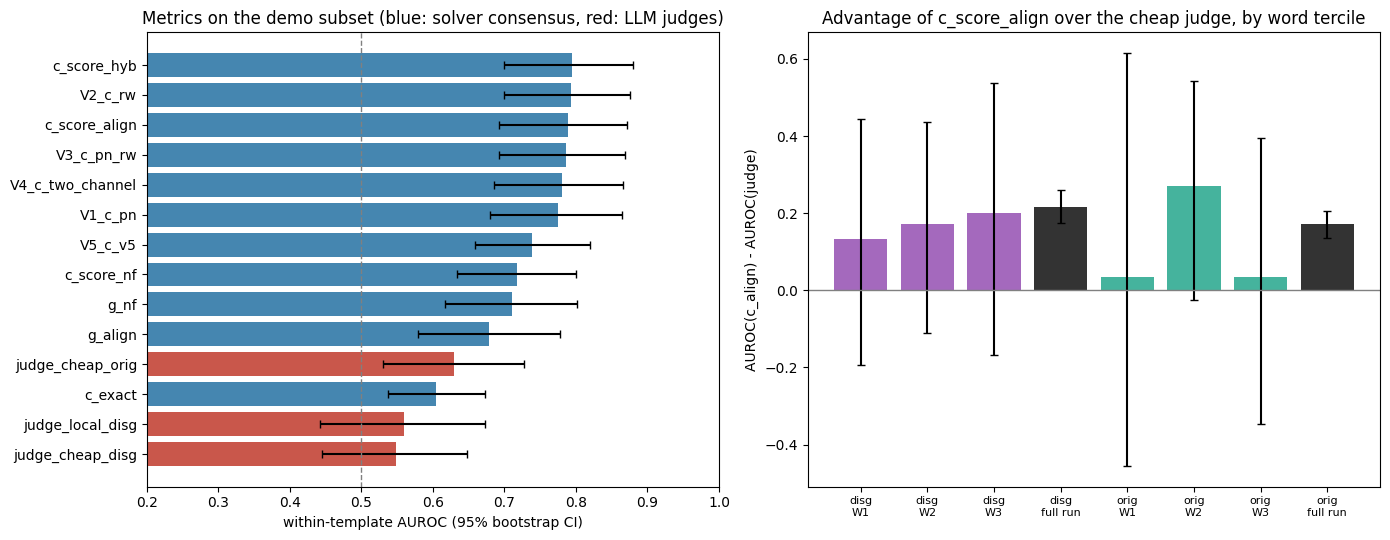

In [16]:
rows_tbl = []
for m, r in A["metrics_untouched_all_scored"].items():
    w, p = r["within_template"], r["pooled"]
    if w.get("est") is None:
        continue
    rows_tbl.append({"metric": m, "n": w["n"], "n_err": w["n_err"], "auroc_within": round(w["est"], 3),
                     "ci_lo": round(w["ci"][0], 3), "ci_hi": round(w["ci"][1], 3), "auroc_pooled": round(p["est"], 3)})
T = pd.DataFrame(rows_tbl).sort_values("auroc_within", ascending=False).reset_index(drop=True)
print("Within-template AUROC (ERROR_CERT vs MAPPED, higher score = ERROR), demo subset:")
print(T.to_string(index=False))

print("\nHeadline, demo vs full run:")
H = pd.DataFrame([{"view": v, "demo_delta": round(A["provisional_headline"][v]["delta"], 3),
                   "demo_ci": [round(x, 3) for x in A["provisional_headline"][v]["ci"]],
                   "full_delta": round(data["full_run_reference"]["provisional_headline"][v]["delta"], 3),
                   "full_ci": [round(x, 3) for x in data["full_run_reference"]["provisional_headline"][v]["ci"]]} for v in ("disg", "orig")])
print(H.to_string(index=False))
print("\nConfirmatory verdict:", A["confirmatory"]["verdict"], "(full run:", data["full_run_reference"]["verdict"] + ")")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
Ts = T.sort_values("auroc_within")
colors = ["#c0392b" if m.startswith("judge") else "#2471a3" for m in Ts.metric]
ax.barh(Ts.metric, Ts.auroc_within, color=colors,
        xerr=[Ts.auroc_within - Ts.ci_lo, Ts.ci_hi - Ts.auroc_within], capsize=3, alpha=0.85)
ax.axvline(0.5, ls="--", color="gray", lw=1)
ax.set_xlim(0.2, 1.0)
ax.set_xlabel("within-template AUROC (95% bootstrap CI)")
ax.set_title("Metrics on the demo subset (blue: solver consensus, red: LLM judges)")

ax = axes[1]
labels, vals, los, his, cols = [], [], [], [], []
for v, c in (("disg", "#8e44ad"), ("orig", "#16a085")):
    for t in ("W1", "W2", "W3"):
        r = A["complexity"][v]["word_tercile"][t]
        if r["delta"] is None:
            continue
        labels.append(f"{v}\n{t}"); vals.append(r["delta"]); los.append(r["delta"] - r["ci"][0]); his.append(r["ci"][1] - r["delta"]); cols.append(c)
    ref = data["full_run_reference"]["provisional_headline"][v]
    labels.append(f"{v}\nfull run"); vals.append(ref["delta"]); los.append(ref["delta"] - ref["ci"][0]); his.append(ref["ci"][1] - ref["delta"]); cols.append("black")
ax.bar(range(len(vals)), vals, yerr=[los, his], color=cols, capsize=3, alpha=0.8)
ax.set_xticks(range(len(vals)), labels, fontsize=8)
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("AUROC(c_align) - AUROC(judge)")
ax.set_title("Advantage of c_score_align over the cheap judge, by word tercile")
plt.tight_layout()
plt.show()